In [1]:
!pip install pandas


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install numpy


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
!pip install matplotlib
!pip install seaborn

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 679.9 kB/s eta 0:00:14
   --- ------------------------------------ 0.8/9.5 MB 824.7 kB/s eta 0:00:11
   ----- ---------------------------------- 1.3/9.5 MB 1.1 MB/s eta 0:00:08
   ------ --------------------------------- 1.6/9.5 MB 1.2 MB/s eta 0:00:07
   ------- -------------------------------- 1.8/9.5 MB 1.2 MB/s eta 0:00:07
   ------- -------------------------------- 1.8/9.5 MB 1.2 MB/s eta 0:00:07
   -------- ------------------------------- 2.1/9.5 MB 1.0 MB/s eta 0:00:08
   --------- ------------------------------ 2.4/9.5 MB 1.1 MB/s eta 0:00:07
   ----------- ---------------------------- 2.6/9.5 MB 1.1 MB/s eta 0:00:07
   ------------- -------------------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# =============================================================
# STAGE 1 — DATA INGESTION, PROFILING & CLEANING
# =============================================================

# Task 1: Load dataset and inspect basic structure
# Understanding shape, column names, dtypes

df = pd.read_csv(r'C:\Users\Ashok Thakur\Desktop\supply_chain_project\data\raw\DataCoSupplyChain.csv', encoding='latin-1')

In [7]:
# Understanding shape
print(df.shape)

(180519, 53)


In [8]:
# Understanding column names, dtypes
print(df.dtypes)

Type                                 str
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                      str
Late_delivery_risk                 int64
Category Id                        int64
Category Name                        str
Customer City                        str
Customer Country                     str
Customer Email                       str
Customer Fname                       str
Customer Id                        int64
Customer Lname                       str
Customer Password                    str
Customer Segment                     str
Customer State                       str
Customer Street                      str
Customer Zipcode                 float64
Department Id                      int64
Department Name                      str
Latitude                         float64
Longitude                        float64
Market          

In [10]:
#checking for missing values
print(df.isnull().sum()[df.isnull().sum() > 0])

Customer Lname              8
Customer Zipcode            3
Order Zipcode          155679
Product Description    180519
dtype: int64


In [15]:
# Task 1A: Data profiling — descriptive stats, duplicates, cardinality
print(df.describe())

       days_for_shipping_real  days_for_shipment_scheduled  benefit_per_order  \
count           180519.000000                180519.000000      180519.000000   
mean                 3.497654                     2.931847          21.974989   
std                  1.623722                     1.374449         104.433526   
min                  0.000000                     0.000000       -4274.979980   
25%                  2.000000                     2.000000           7.000000   
50%                  3.000000                     4.000000          31.520000   
75%                  5.000000                     4.000000          64.800003   
max                  6.000000                     4.000000         911.799988   

       sales_per_customer  late_delivery_risk    category_id    customer_id  \
count       180519.000000       180519.000000  180519.000000  180519.000000   
mean           183.107609            0.548291      31.851451    6691.379495   
std            120.043670        

In [17]:
#checking for duplicates
print("Full duplicates:", df.duplicated().sum())
print("Duplicate order_item_id:", df.duplicated(subset=['order_item_id']).sum())
print(df.nunique().sort_values())

Full duplicates: 0
Duplicate order_item_id: 0
product_description                 0
customer_password                   1
product_status                      1
customer_email                      1
late_delivery_risk                  2
customer_country                    2
customer_segment                    3
delivery_status                     4
days_for_shipment_scheduled         4
shipping_mode                       4
type                                4
market                              5
order_item_quantity                 5
days_for_shipping_real              7
order_status                        9
department_id                      11
department_name                    11
order_item_discount_rate           18
order_region                       23
customer_state                     46
category_name                      50
product_category_id                51
category_id                        51
order_item_product_price           75
product_price                      75
prod

In [11]:
# Task 2: Standardise column names
df.columns = (df.columns
              .str.lower()
              .str.strip()
              .str.replace(' ', '_')
              .str.replace(r'[^a-z0-9_]', '', regex = True))

print(df.columns.tolist())

['type', 'days_for_shipping_real', 'days_for_shipment_scheduled', 'benefit_per_order', 'sales_per_customer', 'delivery_status', 'late_delivery_risk', 'category_id', 'category_name', 'customer_city', 'customer_country', 'customer_email', 'customer_fname', 'customer_id', 'customer_lname', 'customer_password', 'customer_segment', 'customer_state', 'customer_street', 'customer_zipcode', 'department_id', 'department_name', 'latitude', 'longitude', 'market', 'order_city', 'order_country', 'order_customer_id', 'order_date_dateorders', 'order_id', 'order_item_cardprod_id', 'order_item_discount', 'order_item_discount_rate', 'order_item_id', 'order_item_product_price', 'order_item_profit_ratio', 'order_item_quantity', 'sales', 'order_item_total', 'order_profit_per_order', 'order_region', 'order_state', 'order_status', 'order_zipcode', 'product_card_id', 'product_category_id', 'product_description', 'product_image', 'product_name', 'product_price', 'product_status', 'shipping_date_dateorders', 's

In [20]:
# Task 3: Handle missing values
# Drop columns >50% null
# fill numeric nulls with median; drop remaining row nulls
threshold = 0.5
df = df[df.columns[df.isnull().mean() < threshold]]

numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

df.dropna(inplace=True)
print(df.shape)

(180511, 51)


In [ ]:
#dropped 8 rows and 2 columns

In [21]:
# Task 3a: Data validation checks
# To ensures data integrity before any modelling
validation_report = {}
validation_report['negative_spend'] = int((df['sales_per_customer'] < 0).sum())
validation_report['lead_time_outliers'] = int(
    ((df['days_for_shipping_real'] < 0) | (df['days_for_shipping_real'] > 90)).sum()
)
validation_report['duplicate_orders'] = int(df.duplicated(subset=['order_item_id']).sum())
print(validation_report)

{'negative_spend': 0, 'lead_time_outliers': 0, 'duplicate_orders': 0}


In [22]:
# Task 3b: Drop PII and non-analytical columns
# no customer PII or irrelevant URLs required in analytics layer
cols_to_drop = [
    'customer_fname', 'customer_lname', 'customer_email',
    'customer_password', 'customer_street', 'product_image'
]
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
print("Dropped PII/non-analytical columns:", cols_to_drop)

Dropped PII/non-analytical columns: ['customer_fname', 'customer_lname', 'customer_email', 'customer_password', 'customer_street', 'product_image']


In [25]:
# =============================================================
# STAGE 1B — FEATURE ENGINEERING
# =============================================================

# Task 4a: Engineer lead_time_days
# Actual days between order date and shipping date — core risk input

df['order_date_dateorders'] = pd.to_datetime(df['order_date_dateorders'])
df['shipping_date_dateorders'] = pd.to_datetime(df['shipping_date_dateorders'])

df['lead_time_days'] = (df['shipping_date_dateorders'] -
                        df['order_date_dateorders']).dt.days

In [26]:
# Remove negatives and outliers (data entry errors, >90 days)
df = df[(df['lead_time_days'] >= 0) & (df['lead_time_days'] <= 90)]

In [27]:
# Task 4b: Engineer late_delivery_flag
# Binary flag: 1 if shipped after scheduled date, 0 otherwise
df['late_delivery_flag'] = (df['delivery_status']
                            .str.lower()
                            .str.contains('late')
                            .astype(int))

In [28]:
# Task 4c: Engineer spend_per_order
# Total spend = sales per customer × quantity ordered
df['spend_per_order'] = df['sales_per_customer'] * df['order_item_quantity']

In [29]:
# Task 4d: Delivery delay — actual vs scheduled shipping days
# For Better supply chain KPI and for disruption analysis
df['delivery_delay_days'] = (
    df['days_for_shipping_real'] - df['days_for_shipment_scheduled']
)

In [30]:
# Task 4e: Time features for Power BI time intelligence
df['order_year']    = df['order_date_dateorders'].dt.year
df['order_month']   = df['order_date_dateorders'].dt.month
df['order_quarter'] = df['order_date_dateorders'].dt.quarter
df['order_weekday'] = df['order_date_dateorders'].dt.day_name()

In [32]:
# Task 4f: Assigning vendor tier based on spend quantiles
# Strategic / Preferred / Transactional - this will be used as a dimension in Power BI drill-down
VENDOR_COL = 'order_customer_id'       # proxy for supplier (see documentation note)
CATEGORY_COL = 'category_name'
SPEND_COL = 'spend_per_order'

vendor_spend_total = df.groupby(VENDOR_COL)[SPEND_COL].sum()
q66 = vendor_spend_total.quantile(0.66)
q33 = vendor_spend_total.quantile(0.33)

def assign_tier(spend):
    if spend >= q66:   return 'Strategic'
    elif spend >= q33: return 'Preferred'
    else:              return 'Transactional'

tier_map = vendor_spend_total.apply(assign_tier).reset_index()
tier_map.columns = [VENDOR_COL, 'vendor_tier']
df = df.merge(tier_map, on=VENDOR_COL, how='left')

In [38]:
# Task 5: Export cleaned data
import json
with open(r'C:\Users\Ashok Thakur\Desktop\supply_chain_project\docs\validation_report.json', 'w') as f:
    json.dump(validation_report, f, indent=2)

df.to_csv(r'C:\Users\Ashok Thakur\Desktop\supply_chain_project\data\processed\supply_chain_clean.csv', index=False)
print("Clean data exported:", df.shape)

Clean data exported: (180511, 54)


In [ ]:
# =============================================================
# STAGE 1C — EXPLORATORY DATA ANALYSIS
# =============================================================

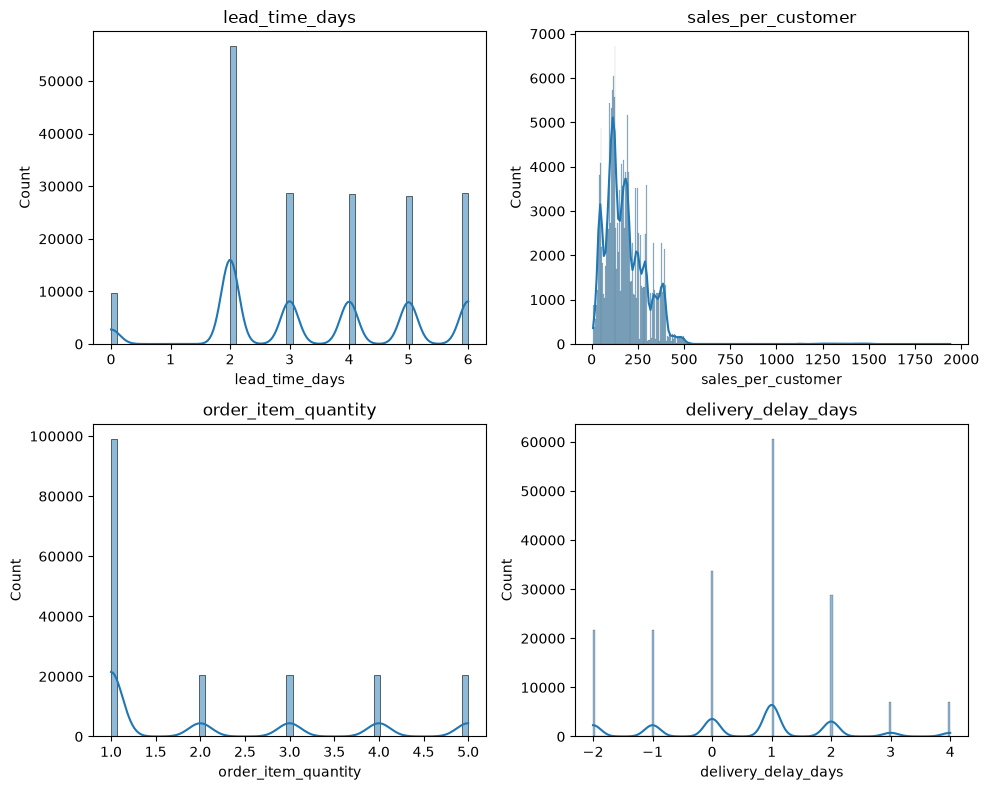

In [49]:
# Task 1C.1: Distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, ['lead_time_days', 'sales_per_customer',
                                 'order_item_quantity', 'delivery_delay_days']):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(r'C:\Users\Ashok Thakur\Desktop\supply_chain_project\docs\eda_distributions.png')
plt.show()
plt.close()

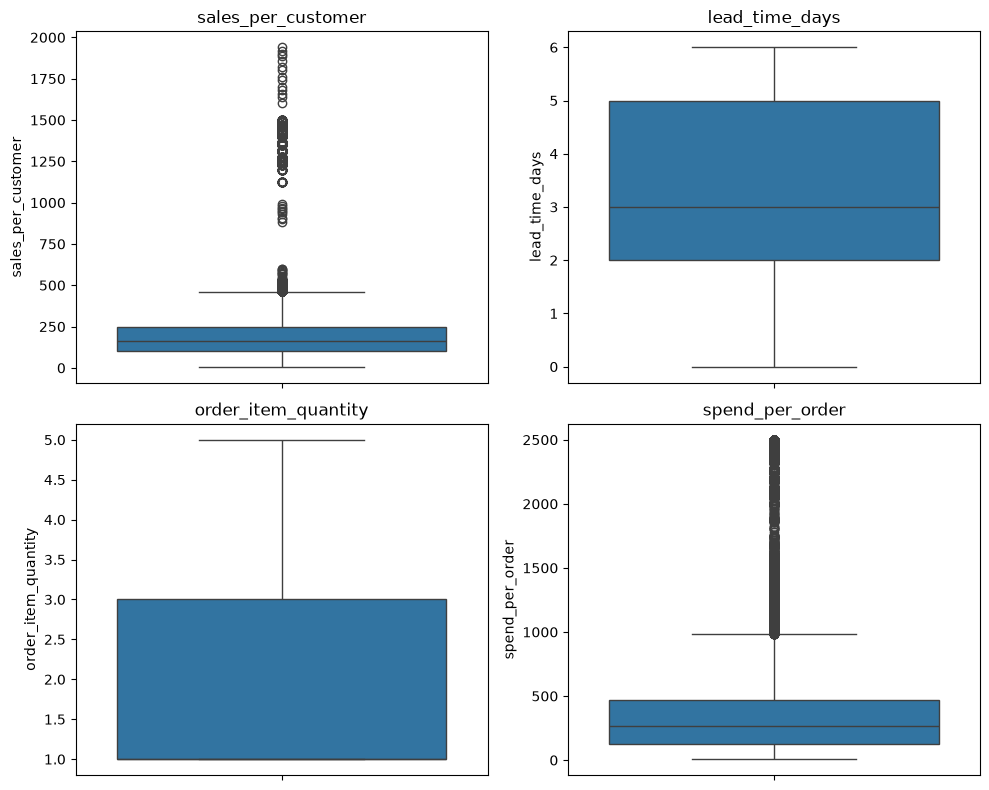

In [52]:
# Task 1C.2: Outlier analysis
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.flat, ['sales_per_customer', 'lead_time_days',
                                 'order_item_quantity', 'spend_per_order']):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.savefig(r'C:\Users\Ashok Thakur\Desktop\supply_chain_project\docs\eda_boxplots.png')
plt.show()
plt.close()

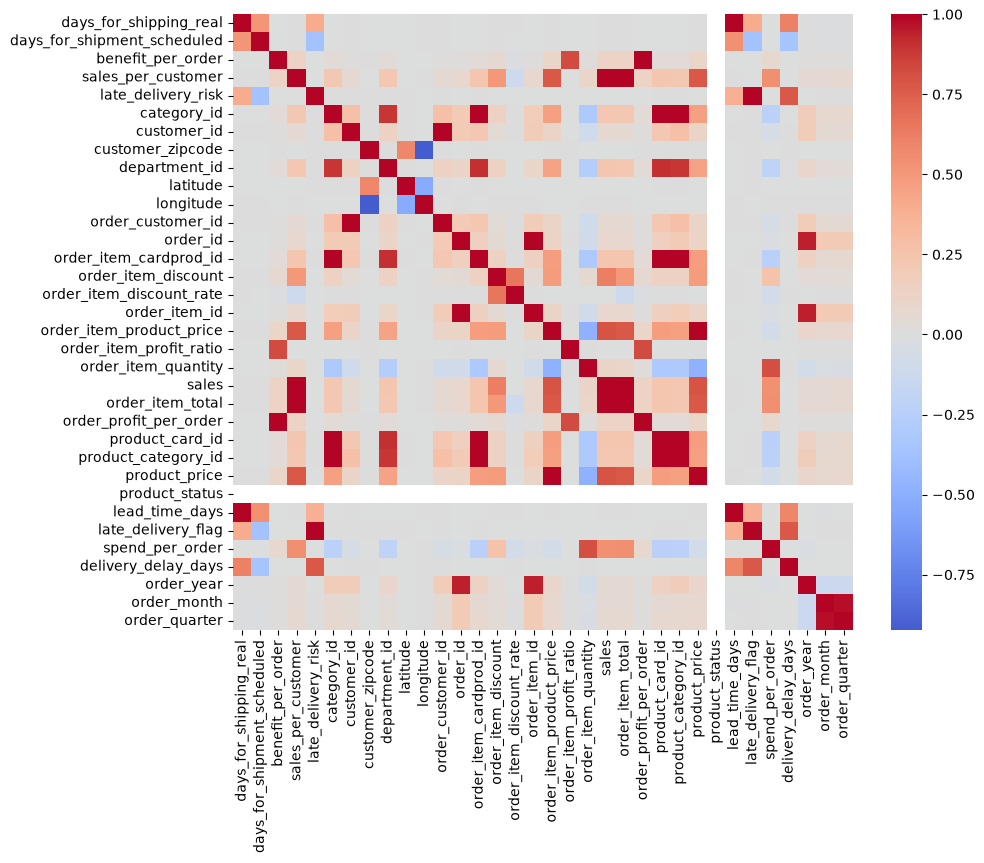

In [45]:
# Task 1C.3: Correlation heatmap
corr = df.select_dtypes(include='number').corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.savefig(r'C:\Users\Ashok Thakur\Desktop\supply_chain_project\docs\eda_correlation_heatmap.png')
plt.show()
plt.close()

In [53]:
df[['order_date_dateorders',
    'shipping_date_dateorders']].head()

,order_date_dateorders,shipping_date_dateorders
0,2018-01-31 22:56:00,2018-02-03 22:56:00
1,2018-01-13 12:27:00,2018-01-18 12:27:00
2,2018-01-13 12:06:00,2018-01-17 12:06:00
3,2018-01-13 11:45:00,2018-01-16 11:45:00
4,2018-01-13 11:24:00,2018-01-15 11:24:00


In [55]:
df.to_csv(
    r'C:\Users\Ashok Thakur\Desktop\supply_chain_project\data\processed\supply_chain_clean.csv',
    index=False,
    encoding='utf-8-sig'
)